In [24]:
print("Hello sssfsfWorld")

Hello sssfsfWorld


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


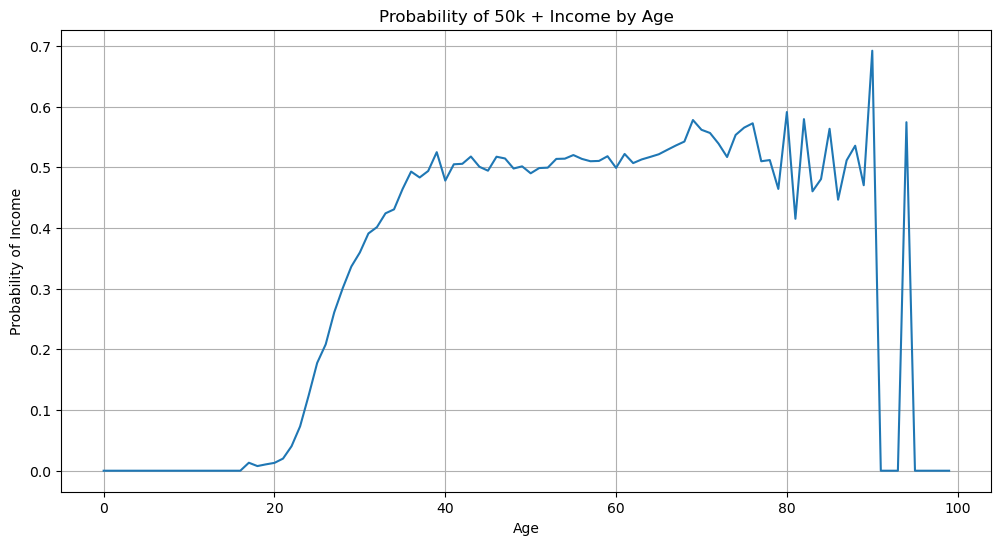

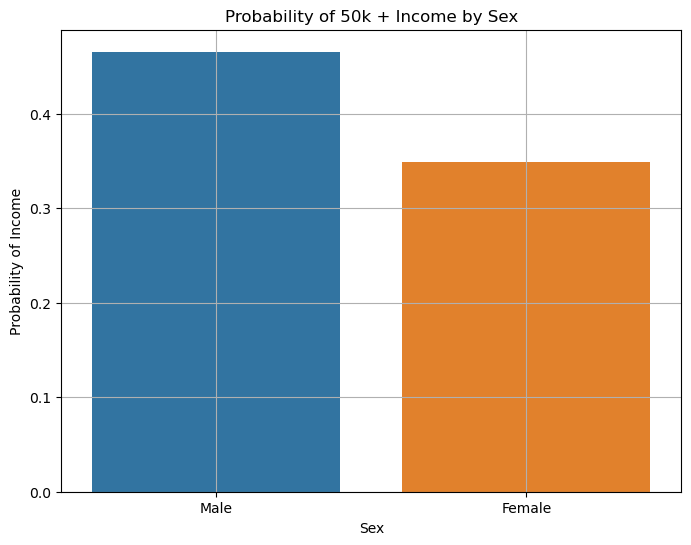

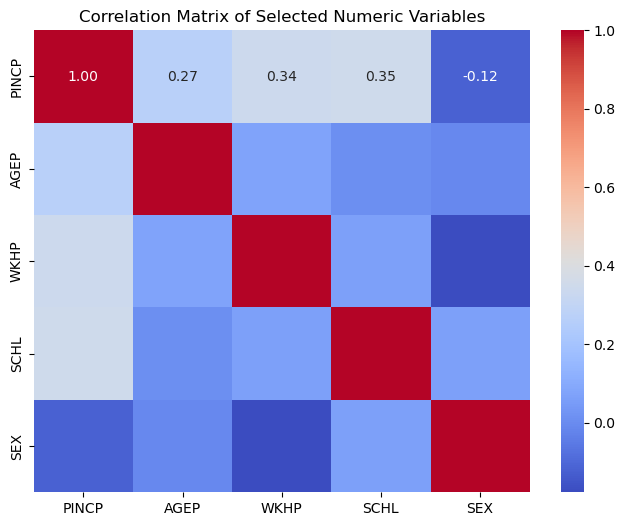

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

labels = pd.read_csv("alt_acsincome_ca_labels_85.csv")
features = pd.read_csv("alt_acsincome_ca_features_85.csv")

df = pd.concat([labels, features], axis=1)
df["PINCP"] = df["PINCP"].map({True: 1, False: 0})

prob_by_sex = df.groupby("SEX")["PINCP"].mean()
sex = np.arange(1, 3)

prob_by_age = df.groupby("AGEP")["PINCP"].mean()
ages = np.arange(0, 100)

plt.figure(figsize=(12, 6))
sns.lineplot(x=ages, y=prob_by_age.reindex(ages, fill_value=0))
plt.title("Probability of 50k + Income by Age")
plt.xlabel("Age")
plt.ylabel("Probability of Income")
plt.grid()
plt.show()

plt.figure(figsize=(8, 6))
sns.barplot(x=sex, y=prob_by_sex.reindex(sex, fill_value=0))
plt.title("Probability of 50k + Income by Sex")
plt.xticks(ticks=[0, 1], labels=["Male", "Female"])
plt.xlabel("Sex")
plt.ylabel("Probability of Income")
plt.grid()
plt.show()

numeric_cols = ["PINCP", "AGEP", "WKHP", "SCHL", "SEX"]

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Selected Numeric Variables")
plt.show()


In [26]:
X = features
y = labels["PINCP"].map({True: 1, False: 0})



features_encoded = pd.get_dummies(features,prefix=['COW','SCHL','MAR','OCCP','POBP','RELP','SEX','RAC1P'], columns = ['COW','SCHL','MAR','OCCP','POBP','RELP','SEX','RAC1P'], drop_first=True, dtype=int)

features_encoded.to_csv('alt_acsincome_ca_features_one_hot_encoded.csv', index=False)


| expérimentation1 | train | test |
|------------------|-------|------|
| Taille jeu de données         | (133052, 808) | (33263, 808)|


In [27]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(features_encoded, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(133052, 808)
(33263, 808)


In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import time

def plot_confusion_matrix(y_true, y_pred, model_name, dataset="Test"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        annot_kws={"color": "black"},
        xticklabels=["Pred 0", "Pred 1"],
        yticklabels=["True 0", "True 1"]
    )
    plt.title(f"{model_name} - {dataset} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()




def evaluate_model(model, model_name):
    print(f"\n===== {model_name} =====")

    # ---- TRAIN ----
    import time
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    # ---- PREDICT ----
    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)

    # ---- METRICS ----
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc  = accuracy_score(y_test, y_test_pred)

    # ---- PRINT SUMMARY ----
    print(f"Train accuracy: {train_acc:.4f}")
    print(f"Test accuracy:  {test_acc:.4f}")
    print(f"Train time:     {train_time:.2f} sec")

    # ---- TEXT CONFUSION MATRICES ----
    cm_test = confusion_matrix(y_test, y_test_pred)
    cm_train = confusion_matrix(y_train, y_train_pred)

    print("\nConfusion Matrix (Test):")
    print(cm_test)

    print("\nConfusion Matrix (Train):")
    print(cm_train)

    # ---- GRAPHICAL CONFUSION MATRICES ----
    plot_confusion_matrix(y_test, y_test_pred, model_name, dataset="Test")
    plot_confusion_matrix(y_train, y_train_pred, model_name, dataset="Train")

    # ---- RETURN ----
    return {
        "model": model_name,
        "train_acc": train_acc,
        "test_acc": test_acc,
        "train_time": train_time,
        "cm_train": cm_train,
        "cm_test": cm_test
    }


models = [
    (RandomForestClassifier(random_state=42), "Random Forest"),
    (AdaBoostClassifier(random_state=42), "AdaBoost"),
    (GradientBoostingClassifier(random_state=42), "Gradient Boosting")
]

results = {}

for model, name in models:
    results[name] = evaluate_model(model, name)



===== Random Forest =====


KeyboardInterrupt: 

| Résultats en entraînement  | Random Forest                    | AdaBoost                            | XGBoost/Gradient Boosting           |
| -------------------------- | -------------------------------- | ----------------------------------- | ----------------------------------- |
| **Accuracy**               | 0.9981                           | 0.7987                              | 0.7995                              |
| **Temps de calcul (sec.)** | 78.64 s                          | 24.18 s                             | 92.94 s                             |
| **Matrice de confusion**   | [[78387, 131],<br> [120, 54414]] | [[65679, 12839],<br>[13947, 40587]] | [[66311, 12207],<br>[14470, 40064]] |



| Résultats en test          | Random Forest                     | AdaBoost                          | XGBoost/Gradient Boosting         |
| -------------------------- | --------------------------------- | --------------------------------- | --------------------------------- |
| **Accuracy**               | 0.8142                            | 0.7970                            | 0.7986                            |
| **Matrice de confusion**   | [[16689, 2905],<br>[3276, 10393]] | [[16357, 3237],<br>[3514, 10155]] | [[16547, 3047],<br>[3652, 10017]] |


In [35]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
print("aa")

aa


In [36]:
param_grid_rf = {
    "n_estimators": [200, 400],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 10],
    "max_features": ["sqrt", "log2"]
}


In [37]:
param_grid_gb = {
    "n_estimators": [100, 300],
    "learning_rate": [0.01, 0.1],
    "max_depth": [3, 5]
}

In [38]:
param_grid_ada = {
    "n_estimators": [50, 200, 400],
    "learning_rate": [0.01, 0.1, 1.0]
}
print("test")

test


In [ ]:
grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid_rf,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_

print("Best Random Forest params:", grid_rf.best_params_)


Fitting 3 folds for each of 24 candidates, totalling 72 fits


In [ ]:
grid_ada = GridSearchCV(
    estimator=AdaBoostClassifier(random_state=42),
    param_grid=param_grid_ada,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_ada.fit(X_train, y_train)
best_ada = grid_ada.best_estimator_

print("Best AdaBoost params:", grid_ada.best_params_)


In [ ]:
grid_gb = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid_gb,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_gb.fit(X_train, y_train)
best_gb = grid_gb.best_estimator_

print("Best Gradient Boosting params:", grid_gb.best_params_)


In [ ]:
results_rf_opt = evaluate_model(best_rf, "Random Forest (Optimisé)")
#results_ada_opt = evaluate_model(best_ada, "AdaBoost (Optimisé)")
#results_gb_opt  = evaluate_model(best_gb, "Gradient Boosting (Optimisé)")


In [ ]:
print("aaaa")